In [62]:
import cv2
import numpy as np
from skimage.morphology import skeletonize, dilation, square
from skimage import data
from matplotlib import pyplot as plt
import math

In [101]:
### SPOT IMAGES ARE 640x480 (WxH) ###


def color_segmentation(img, lower_color, upper_color):
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv_img, lower_color, upper_color)
    ribbon_segment = cv2.bitwise_and(img, img, mask=mask)
    return mask, ribbon_segment

def start(img):
    hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    lower_red1 = np.array([0, 120, 70])
    upper_red1 = np.array([10, 255, 255])
    mask_red1 = cv2.inRange(hsv_image, lower_red1, upper_red1)

    lower_red2 = np.array([170, 120, 70])
    upper_red2 = np.array([180, 255, 255])
    mask_red2 = cv2.inRange(hsv_image, lower_red2, upper_red2)

    mask_red = mask_red1 + mask_red2

    result_image = cv2.bitwise_and(img, img, mask=mask_red)

    img = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB).copy()
    # Convert mask_red to a format compatible with cvtColor
    plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    plt.show()

    gray_img = cv2.cvtColor(result_image, cv2.COLOR_RGB2GRAY)

    
    _, black_white = cv2.threshold(gray_img, 1, 255, cv2.THRESH_BINARY)
    
    plt.title("Binary Image")
    plt.imshow(black_white, cmap='gray')
    plt.show()

    # canny = cv2.Canny(black_white, 150, 200)
    # plt.imshow(canny)
    # plt.show()


    contours, _ = cv2.findContours(black_white, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filter contours based on bounding box size
    min_width = 500
    min_height = 25
    filtered_contours = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if w > min_width and h > min_height:
            filtered_contours.append(contour)

    # Draw bounding boxes on the original image
    for contour in filtered_contours:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(black_white, (x, y), (x + w, y + h), (0, 255, 0), 7)


    # lines = cv2.HoughLinesP(black_white, 1, np.pi / 180, 50, 500, 10)
    # x1max = 0
    # x2max = 0 
    # y1max = 0
    # y2max = 0
    # xmax = 0 
    # ymax = 0 
    
    # if lines is not None:
    #     for points in lines:
    #         x1, y1, x2, y2 = points[0]
    #         print(x1,y1,x2,y2)
    #         cv2.line(black_white, (x1, y1), (x2, y2), (0,0,255),2 )

        plt.imshow(black_white)
        plt.show()



    # # Normalize the image to range [0, 1] for skeletonization
    # black_white_norm = black_white // 255

    # skel_img = skeletonize(black_white_norm).astype(np.uint8)

    # dilated_skeleton = dilation(skel_img, square(3))

    # plt.title("Skeletonized Image")
    # plt.imshow(dilated_skeleton, cmap='gray')
    # plt.axis('off')
    # plt.show()


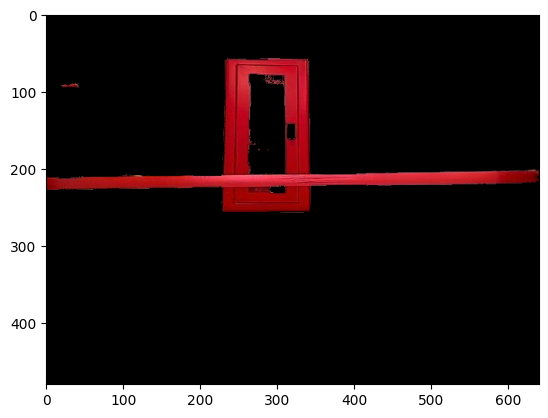

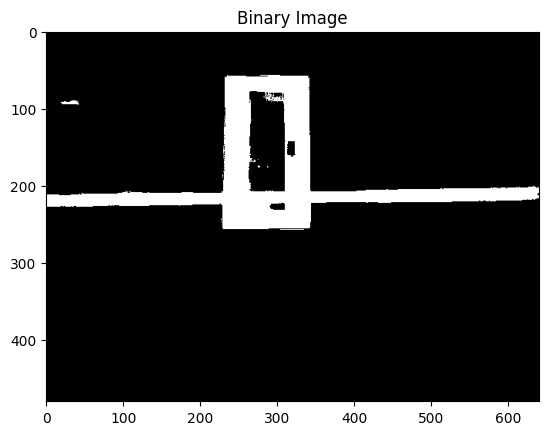

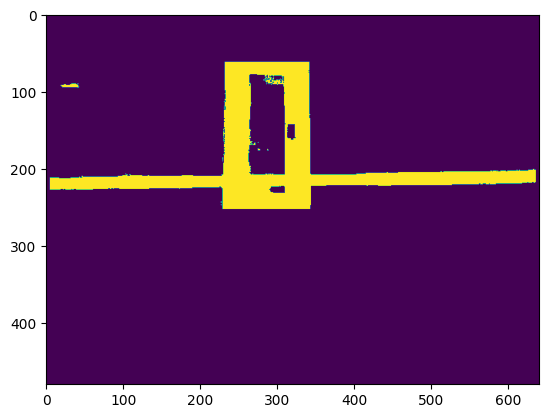

In [102]:
if __name__ == '__main__':
    # cap = cv2.VideoCapture(0)
    # while True:
    #     ret, img = cap.read()
    #     if not ret:
    #         print("Capture failed")
    #         break
    #     start(img)

    img = cv2.imread('/Users/sagar/Documents/GitHub/BDSpot/hand_color_image2.jpg')
    if img is not None:
        start(img)
    else:
        print("Error: Image not found")

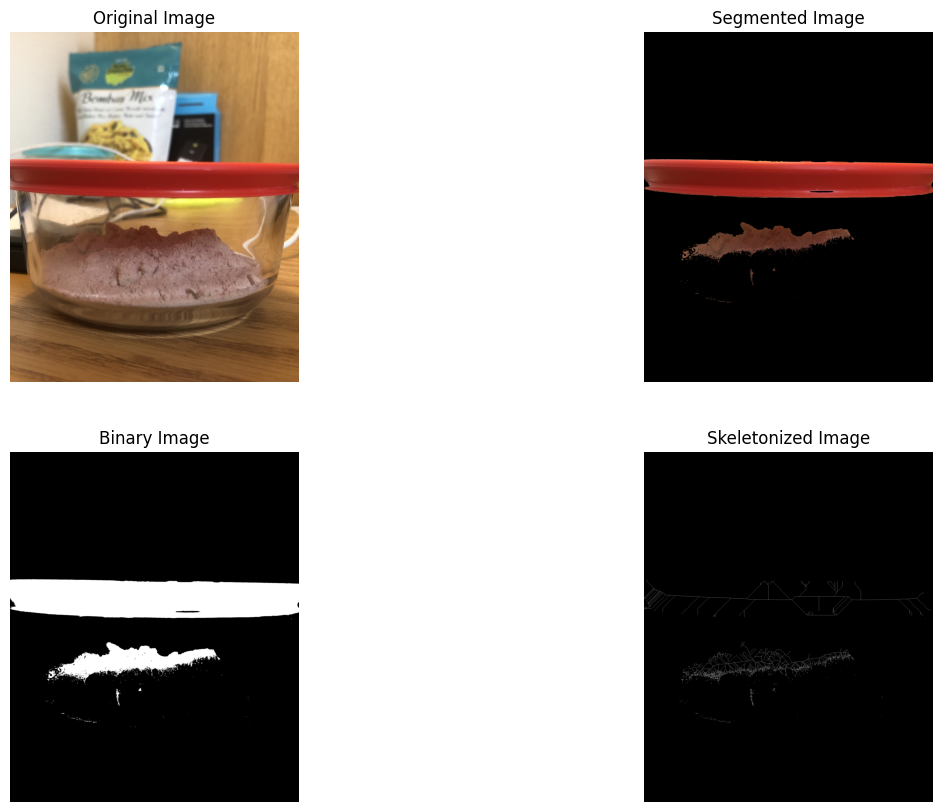

In [14]:
def color_segmentation(img, lower_color, upper_color):
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv_img, lower_color, upper_color)
    ribbon_segment = cv2.bitwise_and(img, img, mask=mask)
    return mask, ribbon_segment

def start(img):
    hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    lower_red1 = np.array([0, 120, 70])
    upper_red1 = np.array([10, 255, 255])
    mask_red1 = cv2.inRange(hsv_image, lower_red1, upper_red1)

    lower_red2 = np.array([170, 120, 70])
    upper_red2 = np.array([180, 255, 255])
    mask_red2 = cv2.inRange(hsv_image, lower_red2, upper_red2)

    mask_red = mask_red1 + mask_red2

    result_image = cv2.bitwise_and(img, img, mask=mask_red)

    # Convert mask_red to a format compatible with cvtColor
    plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    plt.show()

    gray_img = cv2.cvtColor(result_image, cv2.COLOR_RGB2GRAY)
    plt.imshow(gray_img, cmap='gray')
    plt.show()
    
    _, black_white = cv2.threshold(gray_img, 1, 255, cv2.THRESH_BINARY)
    
    plt.title("Binary Image")
    plt.imshow(black_white, cmap='gray')
    plt.show()

    # Normalize the image to range [0, 1] for skeletonization
    black_white_norm = black_white // 255

    skel_img = skeletonize(black_white_norm).astype(np.uint8)

    dilated_skeleton = dilation(skel_img, square(3))

    plt.title("Skeletonized Image")
    plt.imshow(dilated_skeleton, cmap='gray')
    plt.axis('off')
    plt.show()
